In [1]:
import numpy as np
from scipy.sparse.linalg import eigsh, inv
from scipy.sparse import eye, diags, issparse, csr_array, find, hstack, vstack
from scipy.special import comb
from sklearn.metrics.cluster import adjusted_mutual_info_score
from sklearn.cluster import KMeans
import networkx as nx
import sys
import math
import time
from numpy.linalg import eig
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse, Circle
import itertools
import random
from tqdm import tqdm
from _SBMMatrix import *
from _HyperSBM import *
from _HyperCommunityDetection import *
from _FigureJiazeHelper import plot_BH_eigenvalues

%load_ext autoreload
%autoreload 2

# Visualisation Function

In [11]:
# @title
def scatter_spectral(eigvalue, fig=None, ax=None, title='Spectrum', title_x=0.25, node_size=6):
    # Construct scatter coordinate
    x = []
    y = []
    for _w in eigvalue:
        _x = _w.real if isinstance(_w, complex) else _w
        _y = _w.imag if isinstance(_w, complex) else 0
        x.append(_x)
        y.append(_y)
    if fig is None and ax is None:
        fig = plt.figure(figsize=(8, 8))
        widths = [4]
        heights = [4]
        spec5 = fig.add_gridspec(ncols=1, nrows=1, width_ratios=widths, height_ratios=heights)
        row = 0
        col = 0
        ax = fig.add_subplot(spec5[row, col])
    ax.set_aspect('equal',adjustable='box')
    ax.spines['top'].set_color('none')
    ax.spines['right'].set_color('none')
#     ax.xaxis.set_ticks_position('bottom')
    ax.spines['bottom'].set_position(('data', 0))
#     ax.yaxis.set_ticks_position('left')
    ax.spines['left'].set_position(('data', 0))
    ax.scatter(x, y, s=node_size)
    ax.set_title(title, x=title_x)

In [12]:
def plot_NB_eigenvalues(sbm, fig, ax, bulk=None, eig_B=None, ylabel_coor1=(0.25,0.95), ylabel_coor2=(0.2,0.95), 
                       title_x=0.25, xlabel_x=1.02):
    if eig_B is None:
        NB = sbm.get_operator('NB')
        print(np.shape(NB))
        eig_B, _ = eig(NB.toarray())
    info_eig = []
    if bulk is None:
        d = sbm.A.sum(axis=1).flatten().astype(float)
        d = np.sum(d)/np.shape(sbm.A)[0]
        bulk = np.sqrt(d)
    for e in eig_B:
        if abs(e) > bulk and e.imag == 0:
            info_eig.append(e)
    print(info_eig)
    scatter_spectral(eig_B, fig=fig, ax=ax, title=r"Spectrum of $\mathrm{NB}$", title_x=title_x)
    ax.add_patch(Circle(xy = (0.0, 0.0), radius=bulk, alpha=0.2))
    # ax.set_ylim(-bulk-1, 1 * bulk + 1)
    # ax.set_xlim(-bulk-1, max(info_eig).real+1)
    left, right = ax.get_xlim()
    for e in info_eig:
        ax.axvline(e.real, c='black', ls=':', lw=1)
    ax.axvline(bulk, c='black', ls='-', lw=1)
    ax.set_xlabel('real', loc='right', size=15)
    ax.set_ylabel('imag', loc='top', size=15, rotation=0)
    ax.yaxis.set_label_coords(ylabel_coor1[0],ylabel_coor1[1])
    ax.xaxis.set_label_coords(xlabel_x, 0.45)
    y_locs, y_ticks = plt.yticks()
    x_locs, x_ticks = plt.xticks()
    ax.set_aspect('equal',adjustable='box')
    ax.apply_aspect()
    return info_eig

# Community Detection Test

In [87]:
n = 200
q = 2
d = 10
Ks = (2, 3)
epsilon = 0.1
sizes = [int(n / q)] * q
ps_dict = dict()
temp = 0
for k in Ks:
    temp += q * comb(int(n/q), k) * k / (n**k) + epsilon * (comb(n, k) - q * comb(int(n/q), k)) * k / (n**k)
cin = d / temp
cout = epsilon * cin
hsbm = UnUniformSymmetricHSBM(n, q, Ks, cin, cout)

Generating hyper edges for order 2...
Generating hyper edges for order 3...


In [6]:
HBHpartition, HBHnumGroup = HyperCommunityDetect().BetheHessian(hsbm, only_assortative=True)
HBH_ami = adjusted_mutual_info_score(hsbm.groupId, HBHpartition)
print(f"AMI of detected commuinities by HyperBH on HyperSBM is {HBH_ami}")
print(f"Number of detected commuinities by HyperBH on HyperSBM is {HBHnumGroup}")

{2: 1662, 3: 384}
number of groups = 3, Kpos=3
EVECs construct: 0.011004447937011719
AMI of detected commuinities by HyperBH on HyperSBM is 0.4609591822388961
Number of detected commuinities by HyperBH on HyperSBM is 3


In [7]:
HHT = hsbm.H.dot(hsbm.H.T)
HHT = HHT - diags(HHT.diagonal())
HHT_WBHpartition, HHT_WBHnumgroups = CommunityDetect(HHT).BetheHessian(num_groups=3, weighted=True, only_assortative=True)
HHT_WBH_ami = adjusted_mutual_info_score(hsbm.groupId, HHT_WBHpartition)
print(f"Given 3 communities, AMI of detected commuinities by WBH on HHT is {HHT_WBH_ami}")

r=3.492957452131799, Weighted BH build.
r=-3.492957452131799, Weighted BH build.
Given 3 communities, AMI of detected commuinities by WBH on HHT is 0.4470488312419619


In [8]:
lefttop = csr_array(np.zeros((hsbm.n, hsbm.n)))
rightbottom = csr_array(np.zeros((hsbm.e, hsbm.e)))
A_bipartify_H = csr_array(vstack([hstack([lefttop, hsbm.H]), hstack([hsbm.H.transpose(), rightbottom])]))
biH_BHpartition, biH_BHnumgroups = CommunityDetect(A_bipartify_H).BetheHessian(num_groups=None)
biH_ami = adjusted_mutual_info_score(hsbm.groupId, biH_BHpartition[:hsbm.n])
print(f"AMI of detected commuinities by BH on bipartified H is {biH_ami}")
print(f"Number of detected commuinities by BH on bipartified H is {np.size(np.unique(biH_BHpartition[:hsbm.n]))}")

number of groups = 6, Kpos=3, Kneg=3
AMI of detected commuinities by BH on bipartified H is 0.4773880609808591
Number of detected commuinities by BH on bipartified H is 3


# Show NB Spectrum

In [52]:
H_NB = hsbm.get_operator('NB')
print(np.shape(H_NB))
eig_H_NB, _ = eig(H_NB.toarray())
edge_order, edge_count = np.unique(hsbm.H.sum(axis=0).flatten(), return_counts=True)
order_count = dict(zip(edge_order, edge_count))
print(order_count)
ds = dict()
for o in order_count:
    ds[o] = o * order_count[o] / n
bulk = 0
for k in Ks:
    bulk += ds[k] * (k - 1)
bulk = np.sqrt(bulk)

Non-backtrack constructing for 994 directed node-hyperEdge pairs...
994


988036it [05:17, 3107.08it/s]


(994, 994)
{2: 368, 3: 86}


[(12.253398344649142+0j), (4.221610608245476+0j)]


[(12.253398344649142+0j), (4.221610608245476+0j)]

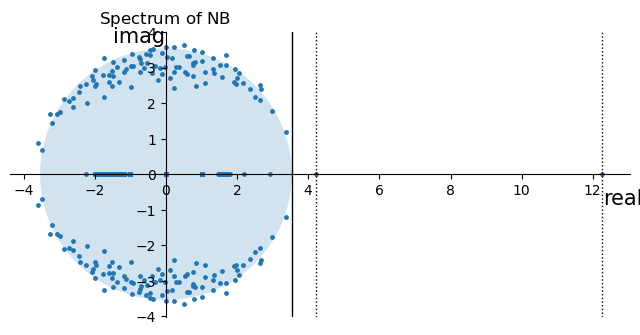

In [53]:
fig = plt.figure(figsize=(8, 8))
ax = plt.subplot(111)
plot_NB_eigenvalues(H_NB, fig, ax, bulk=bulk, eig_B=eig_H_NB)

In [88]:
HHT = hsbm.H.dot(hsbm.H.T)
HHT = HHT - diags(HHT.diagonal())
HHTmatrix = Matrix(n)
HHTmatrix.A = HHT
HHT_WNB = HHTmatrix.get_operator('NB', weighted=True)
print(np.shape(HHT_WNB))
eig_HHT_WNB, _ = eig(HHT_WNB.toarray())
bulk = np.sqrt((HHT**2).sum() / HHT.shape[0])

Non-backtrack constructing for 2320 directed node-hyperEdge...


Constructing Weighted NB Operator: 100%|██████████████████████████████████████████| 2320/2320 [00:02<00:00, 997.16it/s]


(2320, 2320)


In [89]:
print(bulk, eig_HHT_WNB)

3.653765181289022 [ 0.        +0.j 12.44818264+0.j  9.44478883+0.j ...  1.        +0.j
  1.        +0.j  0.        +0.j]


[(12.448182637214604+0j), (9.444788826538305+0j)]


[(12.448182637214604+0j), (9.444788826538305+0j)]

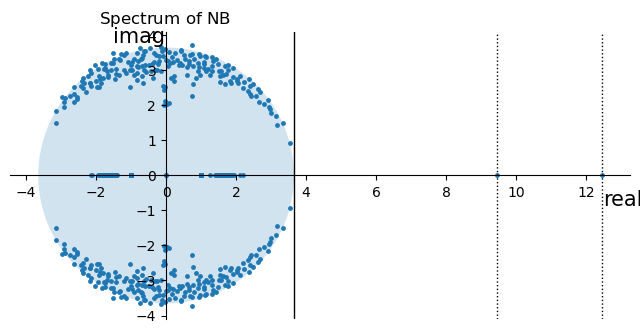

In [90]:
fig = plt.figure(figsize=(8, 8))
ax = plt.subplot(111)
plot_NB_eigenvalues(HHT, fig, ax, bulk=bulk, eig_B=eig_HHT_WNB)

[0. 1. 4. 9.]
border=3.773667451927349, d=12.72
length of rs 100


7.833

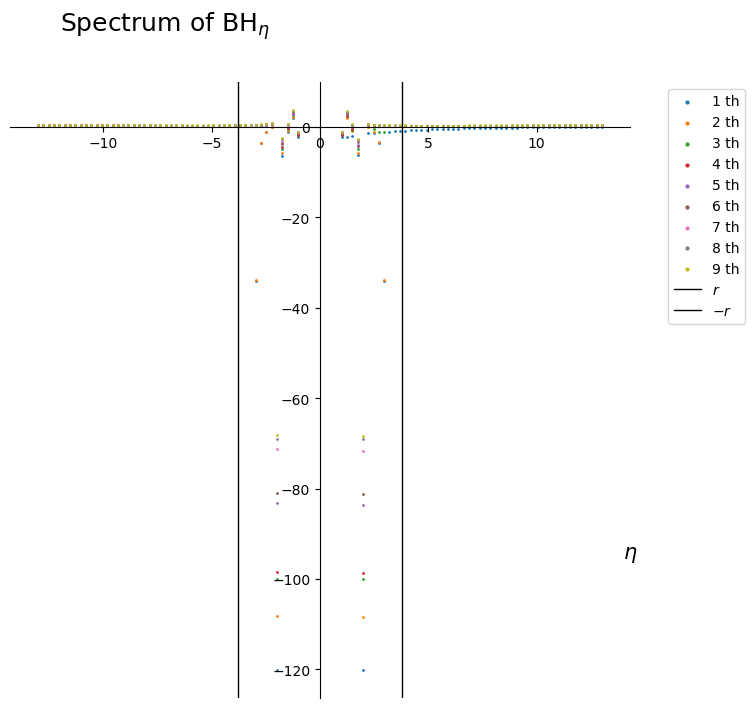

In [86]:
fig = plt.figure(figsize=(8, 8))
ax = plt.subplot(111)
print(np.unique((HHT**2).toarray()))
plot_BH_eigenvalues(HHT, ax, weighted=True, k=10)

# Detectability Limit

In [2]:
from EXPERIMENT_HYPER import *
from matplotlib.ticker import FormatStrFormatter, MaxNLocator

In [3]:
def get_phi(n, q, Ks, d, epsilons):
    phi_1s = []
    phi_2s = []
    for e in epsilons:
        temp = 0
        for k in Ks:
            temp += q * comb(int(n/q), k) * k / (n**k) + e * (comb(n, k) - q * comb(int(n/q), k)) * k / (n**k)
        cin = d / temp
        cout = e * cin
        alphas = dict()
        betas = dict()
        for k in Ks:
            c_kin = (cin + (q**(k-2)-1)*cout) / (q**(k-2) * np.math.factorial(k - 2))
            c_kout = cout / np.math.factorial(k - 2)
            alphas[k] = (c_kin + (q-1) * c_kout) / q
            betas[k] = (c_kin - c_kout) / q
        phi_1 = np.sum([betas[k] for k in betas.keys()]) ** 2 / np.sum([alphas[k] for k in alphas.keys()])
        phi_2 = np.sum([betas[k]**2/alphas[k] for k in Ks])
        phi_1s.append(phi_1)
        phi_2s.append(phi_2)
#     print(phi_1s)
#     print(phi_2s)
    return phi_1s, phi_2s

In [4]:
# Our detectability
def get_piepsilonk(q, e, k):
    return (1+e*(q**(k-1)-1))/(q**(k-1)*np.math.factorial(k))

def get_snr(n, q, Ks, d, epsilons):
    snrs = []
    for e in epsilons:
        Zk = 0
        sumpi = 0
        sumkminus1pi = 0
        sumkpi = 0
        for k in Ks:
            pi_epsilonk = get_piepsilonk(q, e, k)
            Zk += pi_epsilonk
            sumpi += pi_epsilonk
            sumkminus1pi += (k-1)*pi_epsilonk
            sumkpi += k * pi_epsilonk
        prod = 1
        ci = d / sumkpi
        for k in Ks:
            pi_epsilonk = get_piepsilonk(q, e, k)
            prod *= (1/(q**k*np.math.factorial(k)*pi_epsilonk*ci))**(pi_epsilonk/Zk)
        current_snr = q*(1-e)*ci*np.sqrt(d*sumkminus1pi/sumpi)*prod
        snrs.append(current_snr)
    return snrs

In [5]:
def plot_ami(bh_epsilons, bh_results, n, q, d, Ks, 
             fig=None, ax=None, ax_twin=None, limit_line=True,
             ami_label=r'$\rm AMI$', numcommunity_label=r'$\#$'):
    if fig is None and ax is None:
        fig = plt.figure(figsize=(8, 4))
        widths = [4]
        heights = [4]
        spec5 = fig.add_gridspec(ncols=1, nrows=1, width_ratios=widths, height_ratios=heights)
        row = 0
        col = 0
        ax = fig.add_subplot(spec5[row, col])
    # ax.plot(bh_epsilons, bh_results[0], lw=3, c="#20D9FA", label=ami_label)
    ax.plot(bh_epsilons, bh_results[0], lw=3, label=ami_label)
    # ax.plot(bp_epsilons, bp_results[0], lw=3, c="#A4FA83", label=r'$\rm AMI_{BP}$')
    # # plt.axvline(1, color='k', lw=1)
    # # plt.axvline(crit_epsilon, color='red', lw=0.8, ls=':')
    plt.axhline(0, color='gray', lw=0.8, ls=':')
    ax.set_xlabel(r"$\epsilon$", fontsize=20)
    ax.set_ylabel(r"$\rm AMI$", fontsize=20)
    ax.xaxis.set_major_locator(MaxNLocator(5))
    ax.xaxis.set_major_formatter(FormatStrFormatter('%.2f'))
    plt.legend(loc=2, bbox_to_anchor=(1.1, 1),  fontsize=20, markerscale=2, frameon=False)

    if ax_twin is None:
        ax_twin = ax.twinx()
    phi_number = 1000
    min_epsilon = np.min(bh_epsilons)
    max_epsilon = np.max(bh_epsilons)
    phi_epsilons = np.linspace(min_epsilon, max_epsilon, phi_number)
    ones = np.array([1]*phi_number)
    phi_1s, phi_2s = get_phi(n, q, Ks, d, phi_epsilons)
    snrs = get_snr(n, q, Ks, d, phi_epsilons)
    idx_1 = np.argwhere(np.diff(np.sign(phi_1s - ones))).flatten() # cross point
    idx_2 = np.argwhere(np.diff(np.sign(phi_2s - ones))).flatten() # cross point
    idx_3 = np.argwhere(np.diff(np.sign(snrs - ones))).flatten() # cross point
    # ax_twin.axhline(1, color='gray', lw=0.8)
    if limit_line:
        # ax_twin.plot(phi_epsilons, phi_1s, linewidth=0.5, c='#FAAD20', alpha=0.5, label=r'$\phi$')
        # ax_twin.plot(phi_epsilons, phi_2s, linewidth=1, c='red', label=r'$\phi_2$')
        # ax_twin.plot(phi_epsilons, snrs, linewidth=0.5, c='#FA4E20', alpha=0.5, label=r'$\rm snr$')
        ax_twin.axvline(phi_epsilons[idx_1], color='#FAAD20', lw=2, ls='-.', label=r'$\epsilon_{\rm BH}^*$')
        # ax_twin.axvline(phi_epsilons[idx_2], color='red', lw=0.8, ls=':', label=r'$\epsilon_2^*$')
        ax_twin.axvline(phi_epsilons[idx_3], color='#FA4E20', lw=2, ls=':', label=r'$\epsilon_{\rm BP}^*$')
    # ax_twin.scatter(bh_epsilons, bh_results[1],  s=3, c="gray", label=numcommunity_label)
    ax_twin.scatter(bh_epsilons, bh_results[1],  s=3, label=numcommunity_label)
    ax_twin.set_ylabel(r'number of communities')
    # ax_twin.set_yticks([])
    
    plt.legend(loc=2, bbox_to_anchor=(1.1, 0.75),  fontsize=20, markerscale=2, frameon=False)
    # plt.title(f'Detectability for n={n} q={q} d={d} Ks={Ks}')
    return fig, ax, ax_twin

In [25]:
n = 3000
q = 2
d = 10
Ks = (2, 3)
bp = False
addtionTag = "WBH_projection"
fileId = 'amiExpHyper26.02.07' + f'_n={n}_q={q}_d={round(d)}_Ks={Ks}_{"BP" if bp else "BH"}_{addtionTag}'
load_path = "./result/detectabilityHyper/" + fileId + ".txt"
bh_epsilons, bh_results = read_exp(load_path=load_path, add_paths=[])

Additional result adding...


C:\Users\24391\AppData\Local\Temp\ipykernel_13596\875390319.py:13: DeprecationWarning: `np.math` is a deprecated alias for the standard library `math` module (Deprecated Numpy 1.25). Replace usages of `np.math` with `math`
  c_kin = (cin + (q**(k-2)-1)*cout) / (q**(k-2) * np.math.factorial(k - 2))
C:\Users\24391\AppData\Local\Temp\ipykernel_13596\875390319.py:14: DeprecationWarning: `np.math` is a deprecated alias for the standard library `math` module (Deprecated Numpy 1.25). Replace usages of `np.math` with `math`
  c_kout = cout / np.math.factorial(k - 2)
C:\Users\24391\AppData\Local\Temp\ipykernel_13596\1129775213.py:3: DeprecationWarning: `np.math` is a deprecated alias for the standard library `math` module (Deprecated Numpy 1.25). Replace usages of `np.math` with `math`
  return (1+e*(q**(k-1)-1))/(q**(k-1)*np.math.factorial(k))
C:\Users\24391\AppData\Local\Temp\ipykernel_13596\1129775213.py:22: DeprecationWarning: `np.math` is a deprecated alias for the standard library `math` 

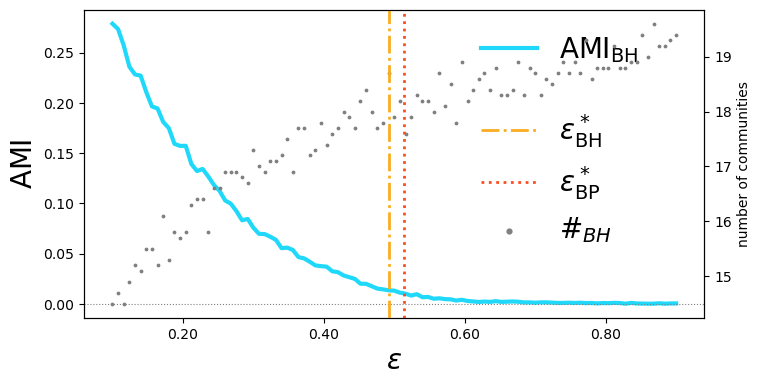

In [39]:
plot_ami(bh_epsilons, bh_results, n, q, d, Ks)

In [42]:
n = 3000
q = 2
d = 10
Ks = (2, 3)
bp = False
addtionTag = "WBH_projection_givenNumGroup"
fileId = 'amiExpHyper26.02.07' + f'_n={n}_q={q}_d={round(d)}_Ks={Ks}_{"BP" if bp else "BH"}_{addtionTag}'
load_path = "./result/detectabilityHyper/" + fileId + ".txt"
bh_epsilons, bh_results = read_exp(load_path=load_path, add_paths=[])

Additional result adding...


C:\Users\24391\AppData\Local\Temp\ipykernel_13596\875390319.py:13: DeprecationWarning: `np.math` is a deprecated alias for the standard library `math` module (Deprecated Numpy 1.25). Replace usages of `np.math` with `math`
  c_kin = (cin + (q**(k-2)-1)*cout) / (q**(k-2) * np.math.factorial(k - 2))
C:\Users\24391\AppData\Local\Temp\ipykernel_13596\875390319.py:14: DeprecationWarning: `np.math` is a deprecated alias for the standard library `math` module (Deprecated Numpy 1.25). Replace usages of `np.math` with `math`
  c_kout = cout / np.math.factorial(k - 2)
C:\Users\24391\AppData\Local\Temp\ipykernel_13596\1129775213.py:3: DeprecationWarning: `np.math` is a deprecated alias for the standard library `math` module (Deprecated Numpy 1.25). Replace usages of `np.math` with `math`
  return (1+e*(q**(k-1)-1))/(q**(k-1)*np.math.factorial(k))
C:\Users\24391\AppData\Local\Temp\ipykernel_13596\1129775213.py:22: DeprecationWarning: `np.math` is a deprecated alias for the standard library `math` 

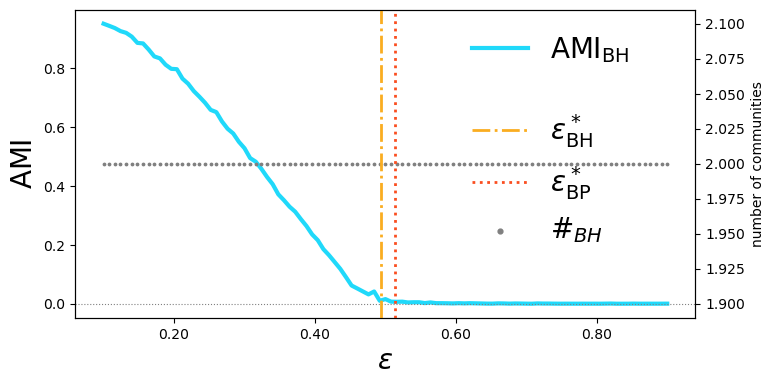

In [43]:
plot_ami(bh_epsilons, bh_results, n, q, d, Ks)

In [91]:
n = 100
q = 2
d = 10
Ks = (2, 3)
bp = False
addtionTag = "WBH_projection"
fileId = 'amiExpHyper26.02.08' + f'_n={n}_q={q}_d={round(d)}_Ks={Ks}_{"BP" if bp else "BH"}_{addtionTag}'
load_path = "./result/detectabilityHyper/" + fileId + ".txt"
bh_epsilons, bh_results = read_exp(load_path=load_path, add_paths=[])

Additional result adding...


C:\Users\24391\AppData\Local\Temp\ipykernel_13596\875390319.py:13: DeprecationWarning: `np.math` is a deprecated alias for the standard library `math` module (Deprecated Numpy 1.25). Replace usages of `np.math` with `math`
  c_kin = (cin + (q**(k-2)-1)*cout) / (q**(k-2) * np.math.factorial(k - 2))
C:\Users\24391\AppData\Local\Temp\ipykernel_13596\875390319.py:14: DeprecationWarning: `np.math` is a deprecated alias for the standard library `math` module (Deprecated Numpy 1.25). Replace usages of `np.math` with `math`
  c_kout = cout / np.math.factorial(k - 2)
C:\Users\24391\AppData\Local\Temp\ipykernel_13596\1129775213.py:3: DeprecationWarning: `np.math` is a deprecated alias for the standard library `math` module (Deprecated Numpy 1.25). Replace usages of `np.math` with `math`
  return (1+e*(q**(k-1)-1))/(q**(k-1)*np.math.factorial(k))
C:\Users\24391\AppData\Local\Temp\ipykernel_13596\1129775213.py:22: DeprecationWarning: `np.math` is a deprecated alias for the standard library `math` 

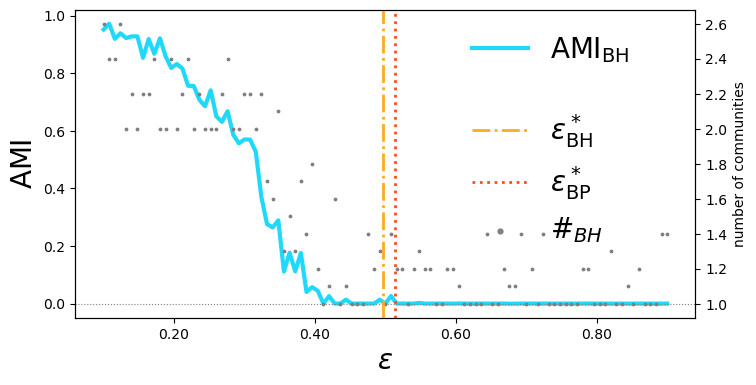

In [92]:
plot_ami(bh_epsilons, bh_results, n, q, d, Ks)

# baseline compare

In [6]:
n = 3000
q = 2
d = 10
Ks = (2, 3)
bp = False
addtionTag = "WBH_projection"
fileId = 'amiExpHyper26.02.08' + f'_n={n}_q={q}_d={round(d)}_Ks={Ks}_{"BP" if bp else "BH"}_{addtionTag}'
load_path = "./result/detectabilityHyper/" + fileId + ".txt"
bh_epsilons, bh_results = read_exp(load_path=load_path, add_paths=[])

Additional result adding...


C:\Users\24391\AppData\Local\Temp\ipykernel_13596\875390319.py:13: DeprecationWarning: `np.math` is a deprecated alias for the standard library `math` module (Deprecated Numpy 1.25). Replace usages of `np.math` with `math`
  c_kin = (cin + (q**(k-2)-1)*cout) / (q**(k-2) * np.math.factorial(k - 2))
C:\Users\24391\AppData\Local\Temp\ipykernel_13596\875390319.py:14: DeprecationWarning: `np.math` is a deprecated alias for the standard library `math` module (Deprecated Numpy 1.25). Replace usages of `np.math` with `math`
  c_kout = cout / np.math.factorial(k - 2)
C:\Users\24391\AppData\Local\Temp\ipykernel_13596\1129775213.py:3: DeprecationWarning: `np.math` is a deprecated alias for the standard library `math` module (Deprecated Numpy 1.25). Replace usages of `np.math` with `math`
  return (1+e*(q**(k-1)-1))/(q**(k-1)*np.math.factorial(k))
C:\Users\24391\AppData\Local\Temp\ipykernel_13596\1129775213.py:22: DeprecationWarning: `np.math` is a deprecated alias for the standard library `math` 

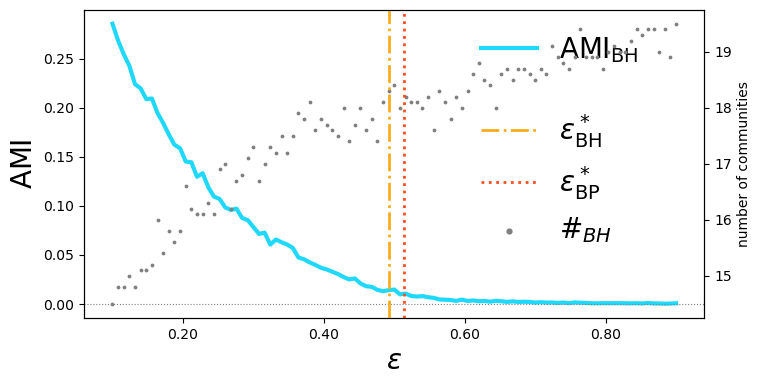

In [94]:
plot_ami(bh_epsilons, bh_results, n, q, d, Ks)

In [11]:
n = 3000
q = 2
d = 10
Ks = (2, 3)
bp = False
addtionTag = ""
# fileId = 'amiExpHyper26.03.18' + f'_n={n}_q={q}_d={round(d)}_Ks={Ks}_BH_{addtionTag}'
givenNumGroup = q
fileId = 'amiExpHyper26.03.24' + f'_n={n}_q={q}_d={round(d)}_Ks={Ks}_BH_givenNumGroup={givenNumGroup}_{addtionTag}'
load_path = "./result/detectabilityHyper/" + fileId + ".txt"
# add_file1 = 'amiExpHyper26.03.21' + f'_n={n}_q={q}_d={round(d)}_Ks={Ks}_BH_0.4~0.6more10'
# add_paths = ["./result/detectabilityHyper/" + f + ".txt" for f in [add_file1]]
add_paths = []
hbh_epsilons, hbh_results = read_exp(load_path=load_path, add_paths=add_paths)

Additional result adding...


In [10]:
n = 3000
q = 2
d = 10
Ks = (2, 3)
addtionTag = ""
fileId = 'amiExpHyper26.03.16' + f'_n={n}_q={q}_d={round(d)}_Ks={Ks}_Louvain_{addtionTag}'
load_path = "./result/detectabilityHyper/" + fileId + ".txt"
add_file1 = 'amiExpHyper26.03.20' + f'_n={n}_q={q}_d={round(d)}_Ks={Ks}_Louvain_0.4~0.6more10'
add_paths = ["./result/detectabilityHyper/" + f + ".txt" for f in [add_file1]]
louvain_epsilons, louvain_results = read_exp(load_path=load_path, add_paths=add_paths)

Additional result adding...


In [9]:
n = 3000
q = 2
d = 10
Ks = (2, 3)
addtionTag = ""
fileId = 'amiExpHyper26.03.20' + f'_n={n}_q={q}_d={round(d)}_Ks={Ks}_SCLaplacian_{addtionTag}'
load_path = "./result/detectabilityHyper/" + fileId + ".txt"
add_file1 = 'amiExpHyper26.03.21' + f'_n={n}_q={q}_d={round(d)}_Ks={Ks}_SCLaplacian_0.4~0.6more10'
add_paths = ["./result/detectabilityHyper/" + f + ".txt" for f in [add_file1]]
laplacian_epsilons, laplacian_results = read_exp(load_path=load_path, add_paths=add_paths)

Additional result adding...


In [8]:
n = 3000
q = 2
d = 10
Ks = (2, 3)
addtionTag = ""
fileId = 'amiExpHyper26.03.18' + f'_n={n}_q={q}_d={round(d)}_Ks={Ks}_BP_{addtionTag}'
load_path = "./result/detectabilityHyper/" + fileId + ".txt"
add_file1 =  'amiExpHyper26.03.21' + f'_n={n}_q={q}_d={round(d)}_Ks={Ks}_BP_0.4~0.6more10'
add_paths = ["./result/detectabilityHyper/" + f + ".txt" for f in [add_file1]]
bp_epsilons, bp_results = read_exp(load_path=load_path, add_paths=add_paths)

Additional result adding...


C:\Users\24391\AppData\Local\Temp\ipykernel_23656\875390319.py:13: DeprecationWarning: `np.math` is a deprecated alias for the standard library `math` module (Deprecated Numpy 1.25). Replace usages of `np.math` with `math`
  c_kin = (cin + (q**(k-2)-1)*cout) / (q**(k-2) * np.math.factorial(k - 2))
C:\Users\24391\AppData\Local\Temp\ipykernel_23656\875390319.py:14: DeprecationWarning: `np.math` is a deprecated alias for the standard library `math` module (Deprecated Numpy 1.25). Replace usages of `np.math` with `math`
  c_kout = cout / np.math.factorial(k - 2)
C:\Users\24391\AppData\Local\Temp\ipykernel_23656\1129775213.py:3: DeprecationWarning: `np.math` is a deprecated alias for the standard library `math` module (Deprecated Numpy 1.25). Replace usages of `np.math` with `math`
  return (1+e*(q**(k-1)-1))/(q**(k-1)*np.math.factorial(k))
C:\Users\24391\AppData\Local\Temp\ipykernel_23656\1129775213.py:22: DeprecationWarning: `np.math` is a deprecated alias for the standard library `math` 

(<Figure size 800x400 with 2 Axes>,
 <Axes: xlabel='$\\epsilon$', ylabel='$\\rm AMI$'>,
 <Axes: ylabel='number of communities'>)

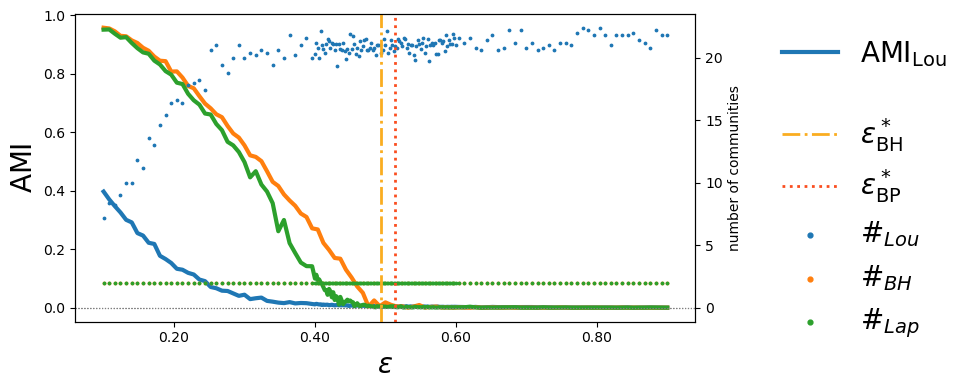

In [13]:
fig, ax, ax_twin = plot_ami(louvain_epsilons, louvain_results, n, q, d, Ks, ami_label=r'$\rm AMI_{Lou}$', numcommunity_label=r'$\#_{Lou}$')
plot_ami(hbh_epsilons, hbh_results, n, q, d, Ks, fig=fig, ax=ax, ax_twin=ax_twin, limit_line=False, 
         ami_label=r'$\rm AMI_{BH}$', numcommunity_label=r'$\#_{BH}$')
plot_ami(laplacian_epsilons, laplacian_results, n, q, d, Ks, fig=fig, ax=ax, ax_twin=ax_twin, limit_line=False, 
         ami_label=r'$\rm AMI_{Lap}$', numcommunity_label=r'$\#_{Lap}$')
# plot_ami(bp_epsilons, bp_results, n, q, d, Ks, fig=fig, ax=ax, ax_twin=ax_twin, limit_line=False, 
#          ami_label=r'$\rm AMI_{BP}$', numcommunity_label=r'$\#_{BP}$')